<a href="https://colab.research.google.com/github/Nihcas001/data_analysis_using_Python/blob/main/08(B)_Advanced%20Matplotlib%20Scientific%20Visualization/research_analysis_using_matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## **1. What is the problem asking?**

The research organization wants to prepare detailed scientific reports.

Therefore, simple graphs are not enough. Researchers often need:

* Customized plots
* Proper titles and axis labels
* Legends
* Annotations
* Multiple plots in one figure
* Error bars
* Mean and variability
* Scientific interpretation

**The important Matplotlib concepts are:**
```
Scientific Dataset
       ↓
   Pandas
       ↓
 Statistical Analysis
       ↓
     Matplotlib
       ↓
 ┌──────────────────────┐
 │ Customized Plot      │
 │ Annotations          │
 │ Legends              │
 │ Subplots             │
 │ Error Visualization  │
 └──────────────────────┘
```

**2. Import Required Libraries**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

**3. Load the Dataset**

In [4]:
# Load the raw experimental dataset
df = pd.read_csv("scientific_experiment_raw_data.csv")

# Display the first five observations
df.head()

,Day,Condition,Replicate,Measurement
0,1,Control,1,52.44
1,1,Control,2,50.85
2,1,Control,3,52.82
3,1,Control,4,55.01
4,1,Control,5,50.61


**4. Understand the Dataset**

In [5]:
# Display number of rows and columns
print("Shape:", df.shape)

# Display column names and data types
print(df.info())

# Display statistical summary
print(df.describe())

Shape: (150, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Day          150 non-null    int64  
 1   Condition    150 non-null    object 
 2   Replicate    150 non-null    int64  
 3   Measurement  150 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 4.8+ KB
None
              Day   Replicate  Measurement
count  150.000000  150.000000   150.000000
mean     5.500000    3.000000    60.793933
std      2.881904    1.418951     7.451464
min      1.000000    1.000000    48.020000
25%      3.000000    2.000000    54.817500
50%      5.500000    3.000000    59.900000
75%      8.000000    4.000000    65.825000
max     10.000000    5.000000    79.950000


**5. Calculate Mean and Standard Deviation**

In [6]:
# Calculate mean and standard deviation for each day and condition
summary = (
    df.groupby(["Day", "Condition"])["Measurement"]
      .agg(["mean", "std"])
      .reset_index()
)

# Display the summary
summary.head(10)

,Day,Condition,mean,std
0,1,Control,52.346,1.773564
1,1,Treatment A,53.094,2.053736
2,1,Treatment B,50.638,2.296981
3,2,Control,50.610,1.628373
4,2,Treatment A,53.670,2.632337
5,2,Treatment B,54.822,1.501073
6,3,Control,54.104,2.899609
7,3,Treatment A,53.948,2.438846
8,3,Treatment B,57.908,2.045341
9,4,Control,54.028,2.680479


**6. Calculate Standard Error**

For scientific reporting, we can also calculate Standard Error of the Mean (SEM).

Formula:

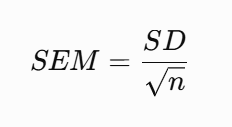


where:
```
SD = Standard deviation
n = number of observations
```
Our dataset contains 5 replicates for each condition/day.

In [7]:
# Count observations for each group
summary = (
    df.groupby(["Day", "Condition"])["Measurement"]
      .agg(["mean", "std", "count"])
      .reset_index()
)

# Calculate standard error of the mean
summary["SEM"] = summary["std"] / np.sqrt(summary["count"])

# Display results
summary.head()

,Day,Condition,mean,std,count,SEM
0,1,Control,52.346,1.773564,5,0.793162
1,1,Treatment A,53.094,2.053736,5,0.918458
2,1,Treatment B,50.638,2.296981,5,1.027241
3,2,Control,50.610,1.628373,5,0.728231
4,2,Treatment A,53.670,2.632337,5,1.177217


**7. Customized Line Plot**

Let's first visualize how the average measurement changes over time.

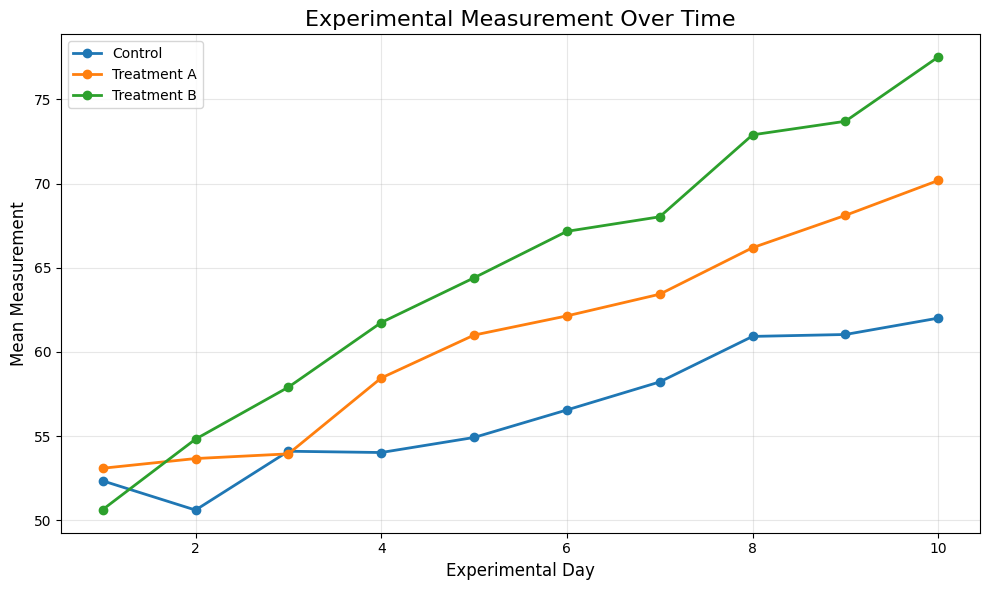

In [8]:
# Create a new figure
plt.figure(figsize=(10, 6))

# Plot each experimental condition
for condition in summary["Condition"].unique():

    # Select data for the current condition
    data = summary[summary["Condition"] == condition]

    # Plot mean measurement over time
    plt.plot(
        data["Day"],
        data["mean"],
        marker="o",
        linewidth=2,
        label=condition
    )

# Add title and axis labels
plt.title("Experimental Measurement Over Time", fontsize=16)
plt.xlabel("Experimental Day", fontsize=12)
plt.ylabel("Mean Measurement", fontsize=12)

# Add legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

# Adjust spacing and display
plt.tight_layout()
plt.show()

**8. Understanding Legends**

A legend tells the reader which line represents which condition.

We use:

`label=condition`

while plotting:
```
plt.plot(
    data["Day"],
    data["mean"],
    label=condition
)
```
Then:

`plt.legend()`

displays the legend.

Without a legend, a scientific reader may not know which line corresponds to Control, Treatment A, or Treatment B.

**9. Add Annotation**

> An annotation highlights an important observation on a graph.

For example, suppose we want to highlight the final measurement for Treatment B.

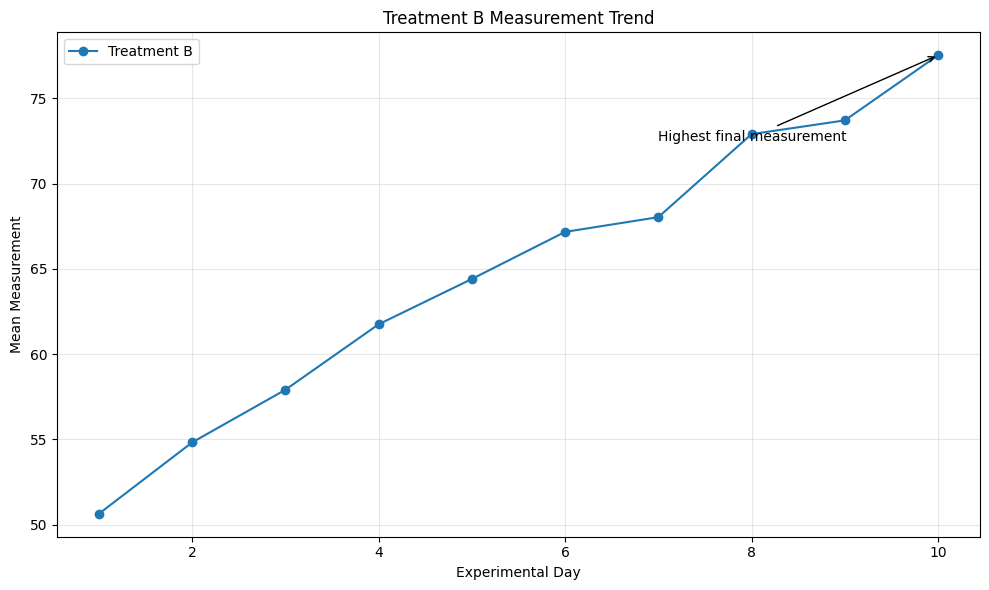

In [9]:
# Select Treatment B data
treatment_b = summary[summary["Condition"] == "Treatment B"]

# Get the final day's observation
last_day = treatment_b.iloc[-1]

# Create the plot
plt.figure(figsize=(10, 6))

# Plot Treatment B
plt.plot(
    treatment_b["Day"],
    treatment_b["mean"],
    marker="o",
    label="Treatment B"
)

# Annotate the final observation
plt.annotate(
    "Highest final measurement",
    xy=(last_day["Day"], last_day["mean"]),
    xytext=(last_day["Day"] - 3, last_day["mean"] - 5),
    arrowprops=dict(arrowstyle="->")
)

# Add labels
plt.title("Treatment B Measurement Trend")
plt.xlabel("Experimental Day")
plt.ylabel("Mean Measurement")

# Add legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**10. Understanding annotate()**

The important part is:
```
plt.annotate(
    "Highest final measurement",
    xy=(last_day["Day"], last_day["mean"]),
    xytext=(last_day["Day"] - 3, last_day["mean"] - 5),
    arrowprops=dict(arrowstyle="->")
)
```
xy: Specifies the point being highlighted.

`xy=(x, y)`

xytext: Specifies where the annotation text should appear.

`arrowprops` : Creates an arrow from the text toward the observation.

So annotations are useful when a researcher wants to draw attention to:

* Maximum value
* Minimum value
* Important experimental event
* Outlier
* Significant change
* Peak response

**11. Error Visualization**

This is one of the most important concepts in scientific plotting.

Suppose the mean measurement is: 60

But the five experimental observations are:

55
58
60
64
63

The mean alone does not tell us how much the observations vary.

Error bars provide information about this variation.

Common error measures include:

* Standard deviation
* Standard error
* Confidence interval

For our example, we'll use SEM.

**12. Error Bars Using errorbar()**

Matplotlib provides:

`plt.errorbar()`

Let's create a scientific plot with **SEM**.

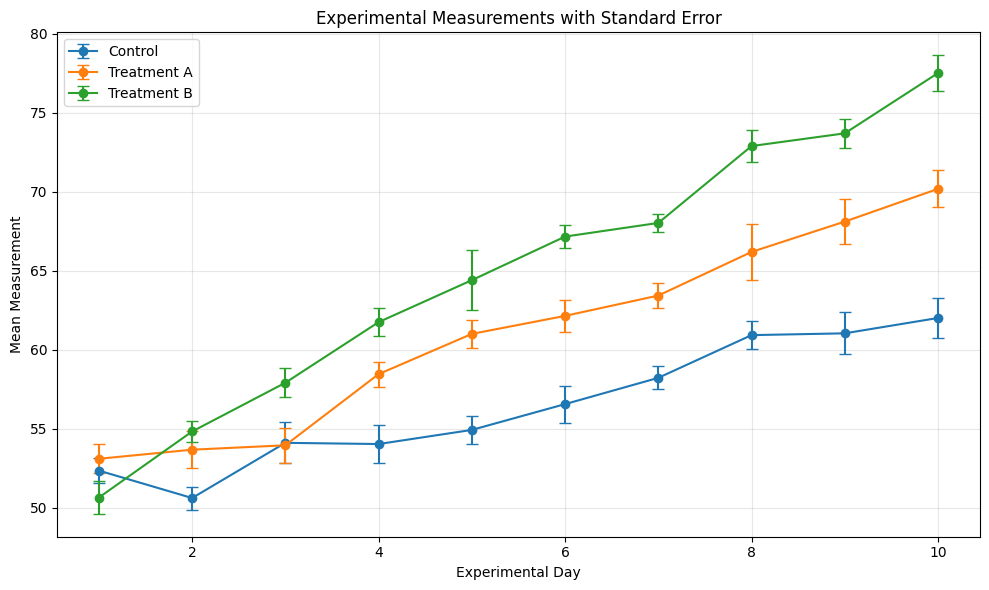

In [11]:
# Create the figure
plt.figure(figsize=(10, 6))

# Plot each experimental condition
for condition in summary["Condition"].unique():

    # Select current condition
    data = summary[summary["Condition"] == condition]

    # Plot mean values with SEM error bars
    plt.errorbar(
        data["Day"],
        data["mean"],
        yerr=data["SEM"],
        marker="o",
        capsize=4,
        label=condition
    )

# Add title and labels
plt.title("Experimental Measurements with Standard Error")
plt.xlabel("Experimental Day")
plt.ylabel("Mean Measurement")

# Add legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

# Display the plot
plt.tight_layout()
plt.show()

**13. Understanding errorbar()**

The key part is:
```
plt.errorbar(
    data["Day"],
    data["mean"],
    yerr=data["SEM"]
)
```
Here:
```
X → Day
Y → Mean Measurement
Error → SEM
```
**yerr** tells Matplotlib how large the vertical error bars should be.

**What is capsize?**

`capsize=4`

adds small horizontal caps to the error bars.

Without caps:

     |
     |
     |
     ●
     |
     |

With caps:

     ─
     |
     |
     ●
     |
     |
     ─

The second representation is generally easier to read.

**14. Why Error Bars Matter**

Suppose two experiments have:
```
Experiment A → Mean = 60, SEM = 1
Experiment B → Mean = 60, SEM = 10
```
Both have the same mean.

But their variability is very different.

Therefore:

> **Mean alone is not always sufficient for scientific reporting.**

Error visualization communicates uncertainty or variability around the estimated value.

**15. Subplots**

**What are Subplots?**

Sometimes researchers want several related graphs in one figure.

For example:
```
┌───────────────────┬───────────────────┐
│ Control           │ Treatment A       │
│                   │                   │
│      Graph        │      Graph        │
├───────────────────┼───────────────────┤
│ Treatment B       │ Comparison        │
│                   │                   │
│      Graph        │      Graph        │
└───────────────────┴───────────────────┘
```

Matplotlib provides: `plt.subplots()`

**16. Basic Subplots**

Let's create three plots in one figure.

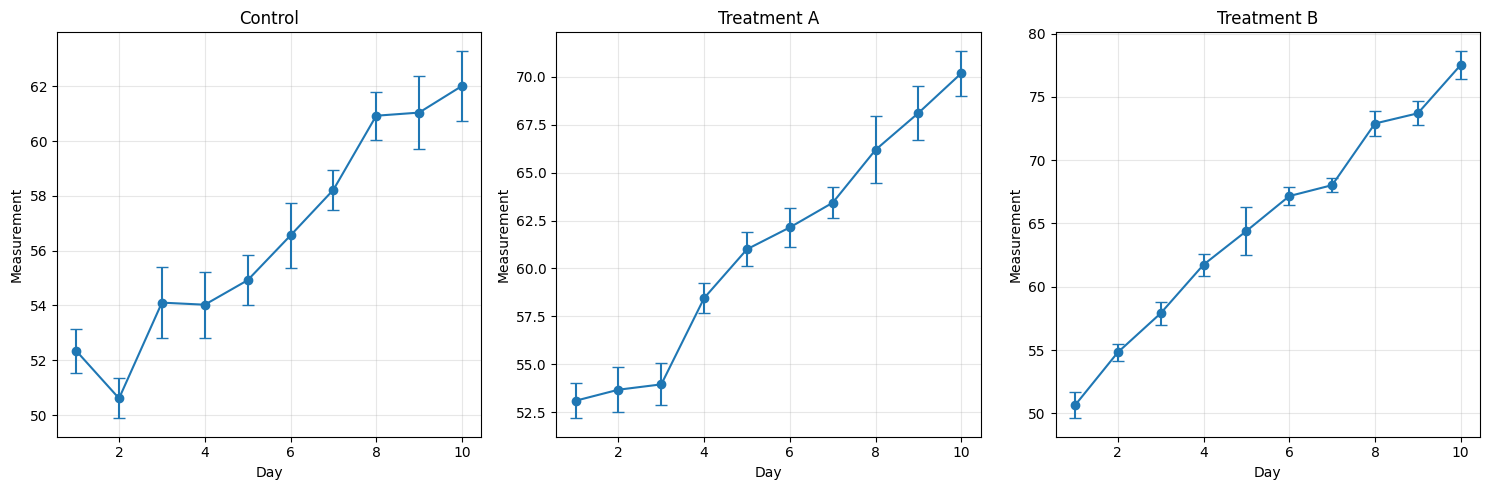

In [14]:
# Create a 1 × 3 subplot layout
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Get unique experimental conditions directly from the dataset
conditions = df["Condition"].unique()

# Loop through each experimental condition
for ax, condition in zip(axes, conditions):

    # Select data for the current condition
    data = summary[summary["Condition"] == condition]

    # Plot mean values with SEM
    ax.errorbar(
        data["Day"],
        data["mean"],
        yerr=data["SEM"],
        marker="o",
        capsize=4
    )

    # Add subplot title and labels
    ax.set_title(condition)
    ax.set_xlabel("Day")
    ax.set_ylabel("Measurement")

    # Add grid
    ax.grid(True, alpha=0.3)

# Adjust spacing between subplots
plt.tight_layout()

# Display the complete figure
plt.show()

**17. Understanding fig and axes**

This statement:

`fig, axes = plt.subplots(1, 3)`

means:
```
1 → number of rows
3 → number of columns
```
Therefore:

`1 × 3 = 3 subplots`

**fig** represents the entire **figure.**

**axes** contains the individual plotting areas.

For example:

`axes[0]` : means the first subplot.

`axes[1]` : means the second subplot.

`axes[2]` : means the third subplot.

**18. Two-by-Two Subplots**

We can also create:

`2 rows × 2 columns`

using:

`fig, axes = plt.subplots(2, 2)`

**Example:**

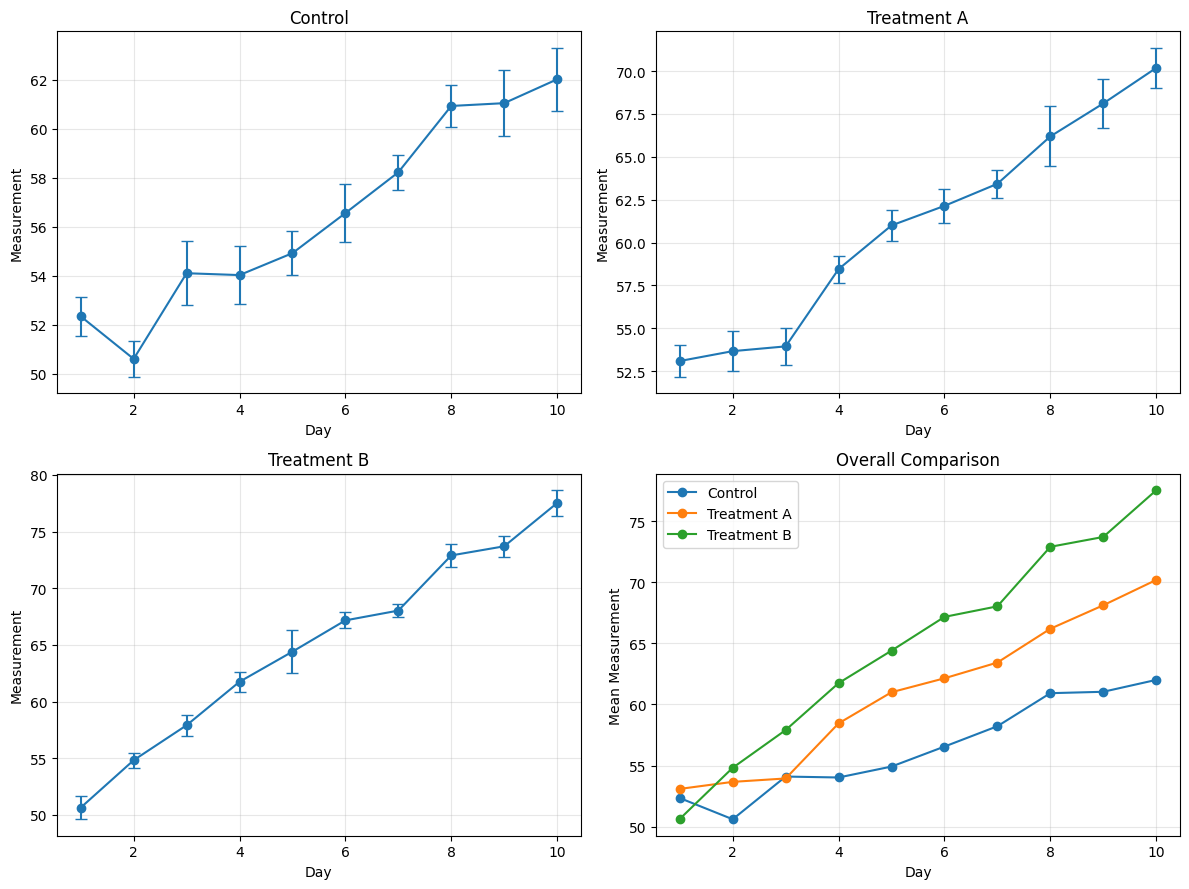

In [15]:
# Create a 2 × 2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Flatten axes so they can be accessed sequentially
axes = axes.flatten()

# Create one subplot for each condition
for i, condition in enumerate(conditions):

    # Select condition-specific data
    data = summary[summary["Condition"] == condition]

    # Plot mean with SEM
    axes[i].errorbar(
        data["Day"],
        data["mean"],
        yerr=data["SEM"],
        marker="o",
        capsize=4
    )

    # Add subplot title and labels
    axes[i].set_title(condition)
    axes[i].set_xlabel("Day")
    axes[i].set_ylabel("Measurement")

    # Add grid
    axes[i].grid(True, alpha=0.3)

# Use the fourth subplot for overall comparison
for condition in conditions:

    # Select current condition
    data = summary[summary["Condition"] == condition]

    # Plot the mean trend
    axes[3].plot(
        data["Day"],
        data["mean"],
        marker="o",
        label=condition
    )

# Configure comparison subplot
axes[3].set_title("Overall Comparison")
axes[3].set_xlabel("Day")
axes[3].set_ylabel("Mean Measurement")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()

# Display figure
plt.show()

This is particularly useful in scientific reports because related analyses can be presented together.

**19. Customized Plot with axhline()**

Researchers may have a reference or threshold value.

For example, suppose the reference measurement is **60.**

We can draw a horizontal reference line:

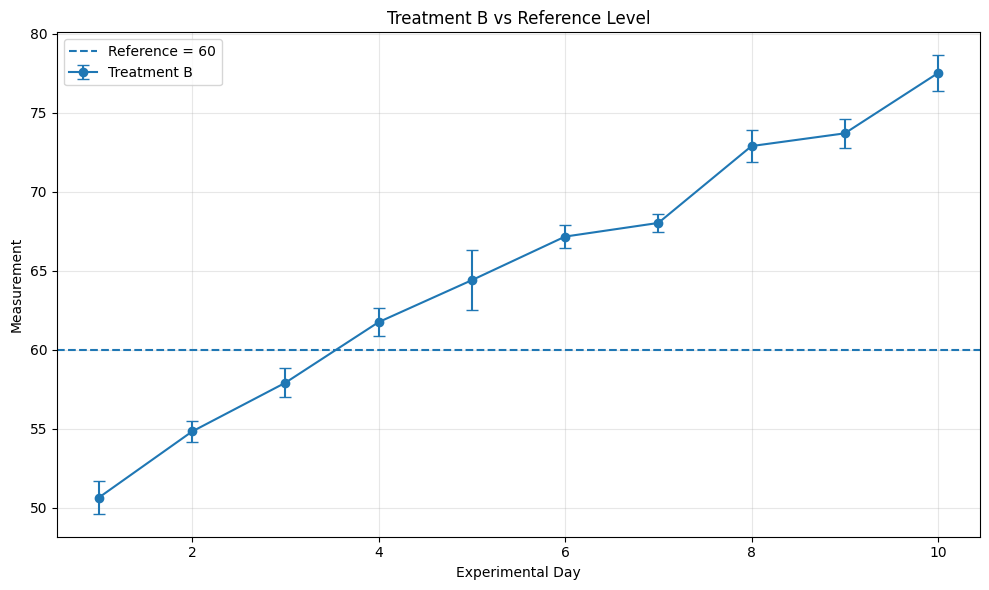

In [16]:
# Select Treatment B
data = summary[summary["Condition"] == "Treatment B"]

# Create figure
plt.figure(figsize=(10, 6))

# Plot mean with SEM
plt.errorbar(
    data["Day"],
    data["mean"],
    yerr=data["SEM"],
    marker="o",
    capsize=4,
    label="Treatment B"
)

# Add reference line
plt.axhline(
    y=60,
    linestyle="--",
    label="Reference = 60"
)

# Add title and labels
plt.title("Treatment B vs Reference Level")
plt.xlabel("Experimental Day")
plt.ylabel("Measurement")

# Add legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**axhline() is useful for:**

* Control/reference values
* Experimental thresholds
* Target values
* Safety limits
* Baseline measurements

**20. Add a Vertical Reference Line**

Similarly, we can use:

`plt.axvline()`

Example:
```
# Add a vertical line at Day 5
plt.axvline(
    x=5,
    linestyle="--",
    label="Intervention Day"
)
```

This can represent an important experimental event.

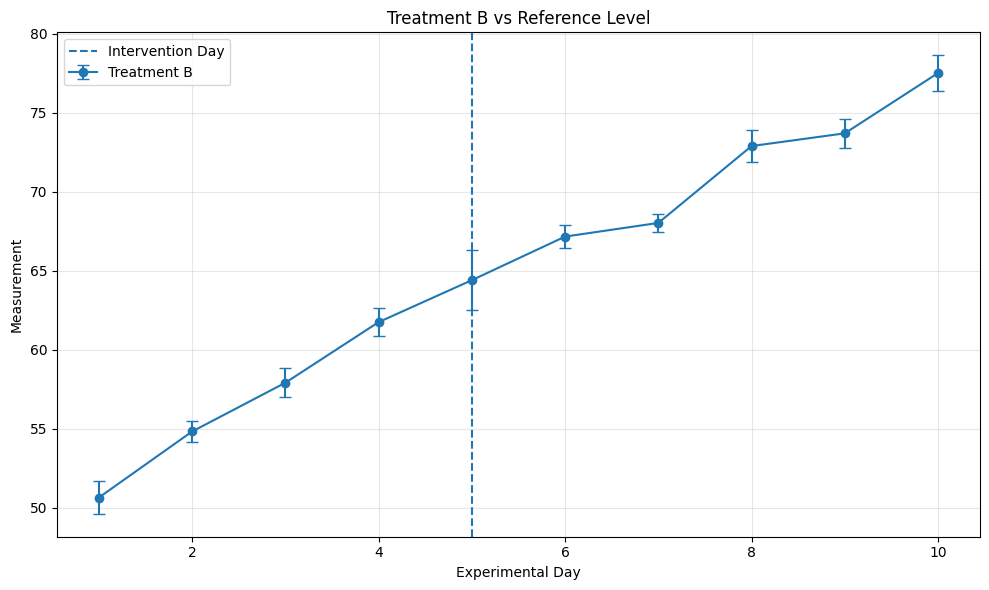

In [17]:
# Select Treatment B
data = summary[summary["Condition"] == "Treatment B"]

# Create figure
plt.figure(figsize=(10, 6))

# Plot mean with SEM
plt.errorbar(
    data["Day"],
    data["mean"],
    yerr=data["SEM"],
    marker="o",
    capsize=4,
    label="Treatment B"
)

# Add reference line
# plt.axhline(
#     y=60,
#     linestyle="--",
#     label="Reference = 60"
# )

# Add a vertical line at Day 5
plt.axvline(
    x=5,
    linestyle="--",
    label="Intervention Day"
)

# Add title and labels
plt.title("Treatment B vs Reference Level")
plt.xlabel("Experimental Day")
plt.ylabel("Measurement")

# Add legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**21. Scientific Report-Quality Plot**

Now let's combine:

* Customization
* Multiple conditions
* Error bars
* Annotation
* Legend
* Grid
* Reference line

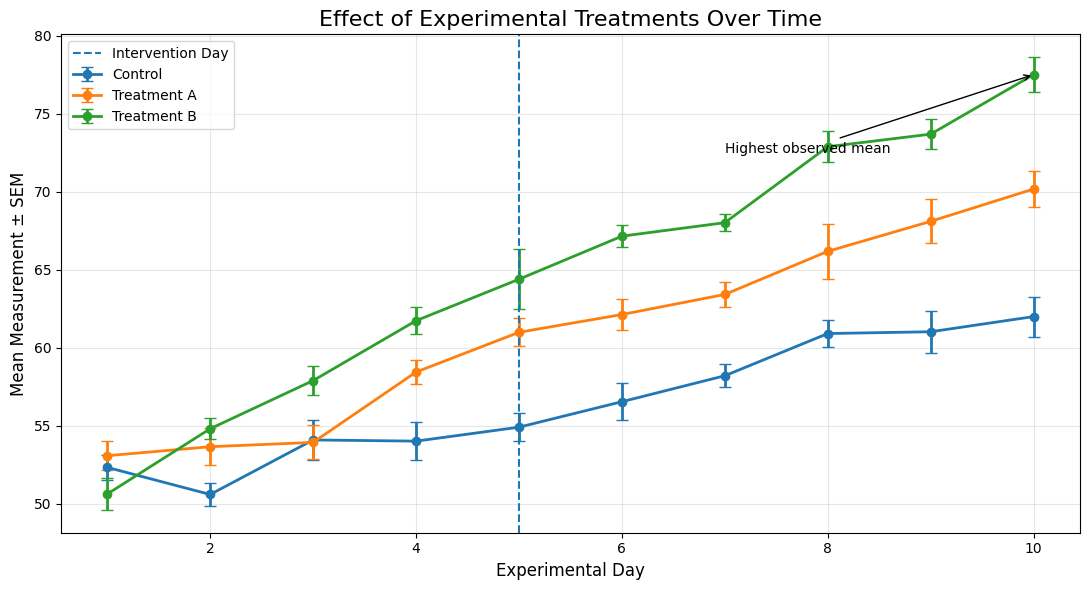

In [18]:
# Create the figure
plt.figure(figsize=(11, 6))

# Plot every experimental condition
for condition in conditions:

    # Select current condition
    data = summary[summary["Condition"] == condition]

    # Plot mean and SEM
    plt.errorbar(
        data["Day"],
        data["mean"],
        yerr=data["SEM"],
        marker="o",
        capsize=4,
        linewidth=2,
        label=condition
    )

# Add intervention/reference line
plt.axvline(
    x=5,
    linestyle="--",
    label="Intervention Day"
)

# Select Treatment B final observation
treatment_b = summary[summary["Condition"] == "Treatment B"]
final_point = treatment_b.iloc[-1]

# Add annotation
plt.annotate(
    "Highest observed mean",
    xy=(final_point["Day"], final_point["mean"]),
    xytext=(final_point["Day"] - 3, final_point["mean"] - 5),
    arrowprops=dict(arrowstyle="->")
)

# Add title and labels
plt.title("Effect of Experimental Treatments Over Time", fontsize=16)
plt.xlabel("Experimental Day", fontsize=12)
plt.ylabel("Mean Measurement ± SEM", fontsize=12)

# Add legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

# Improve layout
plt.tight_layout()

# Display the final plot
plt.show()

This is much closer to what you would expect in a scientific report or research paper.

**22. Saving the Figure**

A research report often requires the graph to be saved as an image.

Use:

In [19]:
# Save the figure as a high-resolution PNG
plt.savefig(
    "scientific_experiment_plot.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the figure
plt.show()

<Figure size 640x480 with 0 Axes>

**What does dpi=300 mean?**

**DPI = Dots Per Inch.**

Higher DPI generally produces a higher-resolution image.

For academic reports and publications, 300 DPI is commonly used for raster images.

**23. Complete Program**

Once students understand each concept, they can execute the complete program below.

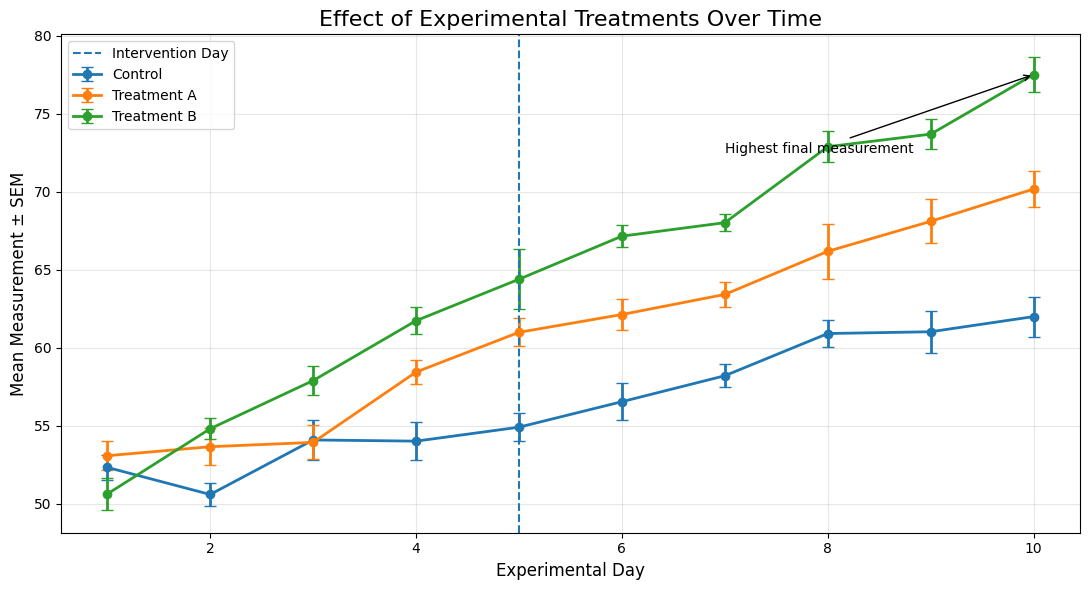

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =====================================================
# STEP 1: LOAD DATA
# =====================================================

# Load raw experimental observations
df = pd.read_csv("scientific_experiment_raw_data.csv")


# =====================================================
# STEP 2: CALCULATE SUMMARY STATISTICS
# =====================================================

# Calculate mean, standard deviation and sample count
summary = (
    df.groupby(["Day", "Condition"])["Measurement"]
      .agg(["mean", "std", "count"])
      .reset_index()
)

# Calculate standard error of the mean
summary["SEM"] = summary["std"] / np.sqrt(summary["count"])


# =====================================================
# STEP 3: CREATE SCIENTIFIC PLOT
# =====================================================

# Create figure
plt.figure(figsize=(11, 6))

# Plot every experimental condition
for condition in summary["Condition"].unique():

    # Select data for the condition
    data = summary[summary["Condition"] == condition]

    # Plot mean with SEM error bars
    plt.errorbar(
        data["Day"],
        data["mean"],
        yerr=data["SEM"],
        marker="o",
        linewidth=2,
        capsize=4,
        label=condition
    )


# =====================================================
# STEP 4: ADD ANNOTATION
# =====================================================

# Select Treatment B data
treatment_b = summary[
    summary["Condition"] == "Treatment B"
]

# Get final observation
final_point = treatment_b.iloc[-1]

# Highlight the final observation
plt.annotate(
    "Highest final measurement",
    xy=(final_point["Day"], final_point["mean"]),
    xytext=(final_point["Day"] - 3,
            final_point["mean"] - 5),
    arrowprops=dict(arrowstyle="->")
)


# =====================================================
# STEP 5: ADD REFERENCE LINE
# =====================================================

# Mark the intervention day
plt.axvline(
    x=5,
    linestyle="--",
    label="Intervention Day"
)


# =====================================================
# STEP 6: CUSTOMIZE GRAPH
# =====================================================

# Add title and axis labels
plt.title(
    "Effect of Experimental Treatments Over Time",
    fontsize=16
)

plt.xlabel("Experimental Day", fontsize=12)
plt.ylabel("Mean Measurement ± SEM", fontsize=12)

# Add legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()


# =====================================================
# STEP 7: SAVE AND DISPLAY
# =====================================================

# Save high-resolution figure
plt.savefig(
    "scientific_experiment_plot.png",
    dpi=300,
    bbox_inches="tight"
)

# Display plot
plt.show()